In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def find_project_root():
    candidates = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parents[3])
    cwd = Path.cwd().resolve()
    candidates.extend([
        cwd,
        cwd / "Grad_Research",
        cwd.parent,
        Path("/content/Grad_Research"),
        Path("/content/drive/MyDrive/Grad_Research"),
        Path("/content/drive/MyDrive/Colab Notebooks/Grad_Research"),
    ])
    for root in candidates:
        if (root / "data").is_dir():
            return root
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        pass
    for root in candidates:
        if (root / "data").is_dir():
            return root
    raise FileNotFoundError("Could not find the project root.")

ROOT = find_project_root()
EXP003_DIR = ROOT / "EXP003" / "results"
EXP006_DIR = ROOT / "EXP006" / "results"
print(f"EXP003: {EXP003_DIR}")
print(f"EXP006: {EXP006_DIR}")

EXP003: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP003/results
EXP006: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP006/results


In [2]:
GAMMA   = 0.1
BANK_ID = 1

def load(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df[["step", "Bias", "RMSE", "MAE"]].astype(float)

# ── uncor_1 ──────────────────────────────────────────────────────────
uncor_methods = {
    "MFI":                  load(EXP003_DIR / f"summary_uncor_{BANK_ID}_MFI.csv"),
    "DQN (normal)":         load(EXP003_DIR / f"summary_uncor_{BANK_ID}_DQN_normal_gamma_{GAMMA}.csv"),
    "DQN (uniform)":        load(EXP003_DIR / f"summary_uncor_{BANK_ID}_DQN_uniform_gamma_{GAMMA}.csv"),
    "DQN+MAP (normal)":     load(EXP006_DIR / f"summary_uncor_{BANK_ID}_DQNmaphess_normal_gamma_{GAMMA}.csv"),
    "DQN+MAP (uniform)":    load(EXP006_DIR / f"summary_uncor_{BANK_ID}_DQNmaphess_uniform_gamma_{GAMMA}.csv"),
}

# ── cor_1 ─────────────────────────────────────────────────────────────
cor_methods = {
    "MFI":                  load(EXP003_DIR / f"summary_cor_{BANK_ID}_MFI.csv"),
    "DQN (normal)":         load(EXP003_DIR / f"summary_cor_{BANK_ID}_DQN_normal_gamma_{GAMMA}.csv"),
    "DQN (uniform)":        load(EXP003_DIR / f"summary_cor_{BANK_ID}_DQN_uniform_gamma_{GAMMA}.csv"),
    "DQN+MAP (normal)":     load(EXP006_DIR / f"summary_cor_{BANK_ID}_DQNmaphess_normal_gamma_{GAMMA}.csv"),
    "DQN+MAP (uniform)":    load(EXP006_DIR / f"summary_cor_{BANK_ID}_DQNmaphess_uniform_gamma_{GAMMA}.csv"),
}

print("uncor_1 steps:", len(next(iter(uncor_methods.values()))))
print("cor_1   steps:", len(next(iter(cor_methods.values()))))

uncor_1 steps: 40
cor_1   steps: 40


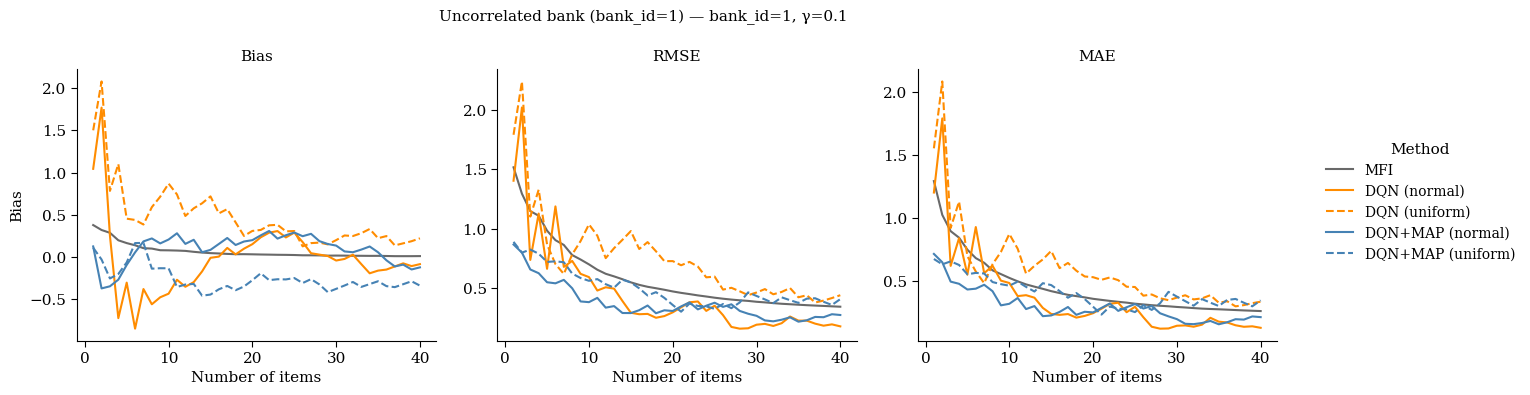

Saved: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP006/results/compare_uncor_1_EXP003_vs_EXP006.png


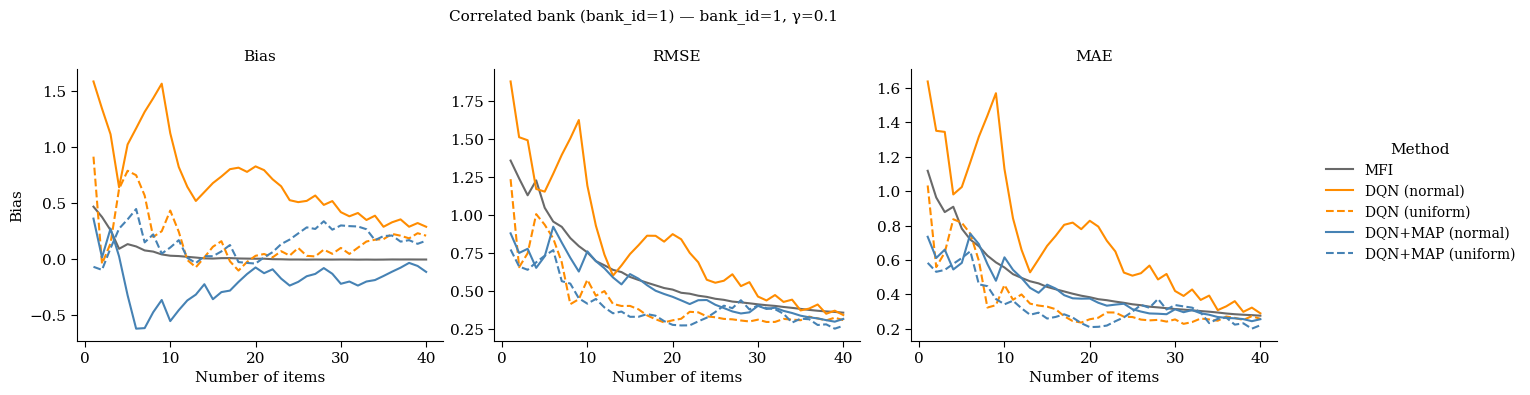

Saved: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP006/results/compare_cor_1_EXP003_vs_EXP006.png


In [3]:
mpl.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.linewidth":    0.8,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
})

# 色 = アルゴリズム系統、線種 = normal(solid) / uniform(dashed)
STYLE = {
    "MFI":               dict(color="dimgray",    ls="-",  lw=1.5),
    "DQN (normal)":      dict(color="darkorange", ls="-",  lw=1.5),
    "DQN (uniform)":     dict(color="darkorange", ls="--", lw=1.5),
    "DQN+MAP (normal)":  dict(color="steelblue",  ls="-",  lw=1.5),
    "DQN+MAP (uniform)": dict(color="steelblue",  ls="--", lw=1.5),
}

METRICS = ["Bias", "RMSE", "MAE"]

def plot_bank(methods, bank_label, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(
        f"{bank_label} — bank_id={BANK_ID}, γ={GAMMA}",
        fontsize=11,
    )
    for col_idx, metric in enumerate(METRICS):
        ax = axes[col_idx]
        for label, df in methods.items():
            ax.plot(df["step"], df[metric], label=label, **STYLE[label])
        ax.set_title(metric, fontsize=11)
        ax.set_xlabel("Number of items", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(metric, fontsize=11)
        ax.set_xticks([0, 10, 20, 30, 40])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Method",
        loc="center right",
        bbox_to_anchor=(1.18, 0.5),
        frameon=False,
        fontsize=10,
        title_fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

# ── 無相関バンク ──────────────────────────────────────────────────────
plot_bank(
    uncor_methods,
    f"Uncorrelated bank (bank_id={BANK_ID})",
    ROOT / "EXP006" / "results" / f"compare_uncor_{BANK_ID}_EXP003_vs_EXP006.png",
)

# ── 有相関バンク ──────────────────────────────────────────────────────
plot_bank(
    cor_methods,
    f"Correlated bank (bank_id={BANK_ID})",
    ROOT / "EXP006" / "results" / f"compare_cor_{BANK_ID}_EXP003_vs_EXP006.png",
)

In [ ]:
# ── 最終ステップ（step=40）の数値比較テーブル ─────────────────────────
rows = []
for bank_key, methods in [("uncor", uncor_methods), ("cor", cor_methods)]:
    for label, df in methods.items():
        last = df[df["step"] == df["step"].max()].iloc[0]
        rows.append({
            "bank":   bank_key,
            "method": label,
            "Bias":   round(last["Bias"], 4),
            "RMSE":   round(last["RMSE"], 4),
            "MAE":    round(last["MAE"],  4),
        })

table = pd.DataFrame(rows).set_index(["bank", "method"])
print(f"=== Final step (step={int(df['step'].max())}) ===")
display(table)